# Angel's Landing
We try to produce a landscape with a vertical dyke

![Angel's Landing](AngelsLanding.jpeg)

In [1]:
from fastscape.models import basic_model
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
%load_ext xsimlab.ipython

In [25]:
nx,ny = 401,401
xl,yl = 40e3,40e3
x,y = np.meshgrid(np.linspace(0,xl,nx), np.linspace(0,yl,ny))
x = xr.DataArray(x, dims=('y','x'), coords={'x':np.linspace(0,xl,nx), 'y':np.linspace(0,yl,ny)})
y = xr.DataArray(y, dims=('y','x'), coords={'x':np.linspace(0,xl,nx), 'y':np.linspace(0,yl,ny)})
kf = xr.where((x-9.7e3)*(x-10.3e3)<0, 0.4e-5, 1e-5)

In [26]:
# %create_setup basic_model
import xsimlab as xs

ds_in = xs.create_setup(
    model=basic_model,
    clocks={'time':np.linspace(0,3e6,101)},
    input_vars={
        'grid__shape': [ny,nx],
        'grid__length': [yl,xl],
        'boundary__status': 'fixed_value',
        'uplift__rate': 1e-4,
        'spl__k_coef': kf,
        'spl__area_exp': 0.45,
        'spl__slope_exp': 1,
        'diffusion__diffusivity': 0.1,
        'init_topography__seed': None,
    },
    output_vars={'topography__elevation':'time',
                 'spl__k_coef':'time',
                 'drainage__area':'time',}
)


In [27]:
with basic_model, xs.monitoring.ProgressBar():
    ds_out = (ds_in
              .xsimlab.run())

             0% | initialize 

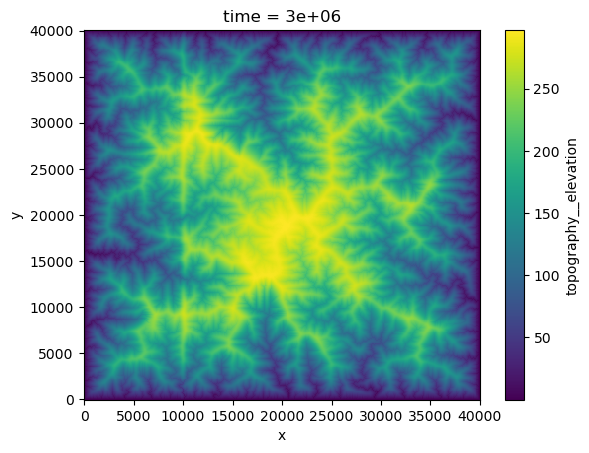

In [28]:
ds_out.topography__elevation.isel(time=-1).plot()

In [29]:
ds_out.x.attrs["units"]= "m"
ds_out.y.attrs["units"]= "m"
ds_out.time.attrs["units"]= "years"

(ds_out.topography__elevation).to_netcdf('Topo.nc')
(ds_out.drainage__area).to_netcdf('Area.nc')
(ds_out.spl__k_coef).to_netcdf('Hardness.nc')
